# Simulación de un sismo en un edificio de dos pisitos

Haciendo una analogía con un sistema masa-resorte-amortiguador por cada piso, revisar si el edificio soporta una frecuencia sostenida de un sismo con parámetros conocidos.

---
1. A través de una IA generativa, obtenga el modelo en de un sistema de dos masas acopladas por resortes y amortiguadores usando el método de integración de su preferencia en un ciclo for. Asegurese de que la primer masa (y solo la primera) tenga una entrada de fuerza la cual emulará el sismo.
2. Usando Enfriamiento simulado, encuentre la frecuencia de resonancia del sistema, esto es, la frecuencia que desplaza más al edificio con la misma amplitud. Considere el sismo como una entrada senoidal con límites de frecuencia tal que $0.001\leq f\leq0.5$ (es decir, fuerza del sismo=$\sin(2\pi f)$).
3. ¿Cuál es la frecuencia que genera mayor desplazamiento? ¿Considera que, bajo los parámetros simulados, el sistema soporta un sismo con esas características?


**Objetivo:**  
1) Modelar un sistema masa–resorte–amortiguador de **dos pisos**.  
2) Excitar con una fuerza senoidal **solo en el piso 1**: $$F(t)=F_0\sin(2\pi f t).  $$
3) Usar **Enfriamiento Simulado** para encontrar la frecuencia $$f\in[0.001,0.5]\ \text{Hz}\$$ que **maximiza el desplazamiento** (resonancia empírica).  
4) Mostrar resultados (frecuencia óptima, desplazamientos máximos y gráficas).

**Parámetros base (editables):** masas `m1, m2`, rigideces `k1, k2`, amortiguamientos `c1, c2`, amplitud de fuerza `F0`.  
Integración con **RK4** y todo en **NumPy**.

> Nota: “mayor desplazamiento” = amplitud pico–pico/2.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del modelo
m1, m2 = 1000.0, 1000.0          # masas [kg]
k1, k2  = 1.0e6, 0.8e6           # rigideces [N/m]
c1, c2  = 8.0e3, 6.0e3           # amortiguamientos [N·s/m]

F0      = 5.0e4                  # amplitud de fuerza [N] (en el piso 1)
f_min, f_max = 0.001, 0.5        # rango de búsqueda [Hz]

# Tiempo de simulación
T_total = 60.0                   # [s] cubrir varias oscilaciones hasta 0.5 Hz (T=2s)
dt      = 0.005                  # [s] paso de integración (RK4)
t = np.arange(0, T_total, dt)

# Ventana final (fracción del tiempo) para medir amplitud
frac_medicion = 0.5  # usar último 50% del registro


In [3]:
def derivadas(x, f_hz, t):
    """
    x = [x1, v1, x2, v2]
    Ecuaciones:
        m1*x1'' + c1*x1' + k1*x1 + c2*(x1' - x2') + k2*(x1 - x2) = F0*sin(2π f t)
        m2*x2'' + c2*(x2' - x1') + k2*(x2 - x1) = 0
    """
    x1, v1, x2, v2 = x
    omega = 2*np.pi*f_hz
    F = F0*np.sin(omega*t)

    # Fuerzas internas
    # Piso 1: resorte y amortiguador a tierra (k1, c1) + acoplamiento a piso 2 (k2, c2)
    # Piso 2: solo acoplamiento con piso 1 (k2, c2)
    a1 = (F - c1*v1 - k1*x1 - c2*(v1 - v2) - k2*(x1 - x2))/m1
    a2 = (      - c2*(v2 - v1) - k2*(x2 - x1))/m2

    return np.array([v1, a1, v2, a2], dtype=float)

def rk4_step(x, f_hz, t, dt):
    k1_ = derivadas(x, f_hz, t)
    k2_ = derivadas(x + 0.5*dt*k1_, f_hz, t + 0.5*dt)
    k3_ = derivadas(x + 0.5*dt*k2_, f_hz, t + 0.5*dt)
    k4_ = derivadas(x + dt*k3_,     f_hz, t + dt)
    return x + (dt/6.0)*(k1_ + 2*k2_ + 2*k3_ + k4_)


In [4]:
def simular_frecuencia(f_hz, x0=None):
    """
    Integra el sistema para una frecuencia f_hz.
    Devuelve:
      t, X -> tiempos y matriz [N,4] con [x1, v1, x2, v2]
      amp1, amp2 -> amplitud (pico-pico/2) al final de la simulación para x1 y x2
    """
    if x0 is None:
        x = np.zeros(4)  # [x1, v1, x2, v2]
    else:
        x = np.array(x0, dtype=float)

    X = np.zeros((len(t), 4), dtype=float)
    for i, ti in enumerate(t):
        X[i] = x
        x = rk4_step(x, f_hz, ti, dt)

    # Tomar la última fracción de la señal para medir amplitud estable
    i0 = int((1.0 - frac_medicion)*len(t))
    x1_tail = X[i0:, 0]
    x2_tail = X[i0:, 2]

    # Amplitud pico-pico/2 (aprox)
    amp1 = 0.5*(np.max(x1_tail) - np.min(x1_tail))
    amp2 = 0.5*(np.max(x2_tail) - np.min(x2_tail))
    return t, X, amp1, amp2


## Búsqueda por Enfriamiento Simulado

- Variable a optimizar: **frecuencia** $$f\in[0.001,0.5] Hz$$
- **Función objetivo**: $$J(f)=\max(\text{amp}_1,\text{amp}_2)$$ la mayor amplitud entre los dos pisos.  
- Propuestas: $$f' = \text{clip}(f + \mathcal{N}(0,\sigma), [f_{\min}, f_{\max}])$$
- Aceptación: si mejora, aceptar; si empeora, aceptar con prob. $$\exp(\Delta/T)$$
- Enfriamiento: $$T_k = T_0\cdot \alpha^k\$$


In [5]:
rng = np.random.default_rng(2025)

def enfriamiento_simulado(
    n_iter=60, T0=1.0, alpha=0.92, sigma_ini=0.05,
    f_ini=None, verbose=True
):
    # inicial
    f = f_ini if f_ini is not None else rng.uniform(f_min, f_max)
    _, _, a1, a2 = simular_frecuencia(f)
    J = max(a1, a2)

    f_best, J_best = f, J
    T = T0
    sigma = sigma_ini

    hist = [(0, f, J)]

    for k in range(1, n_iter+1):
        # proponer nuevo f
        f_prop = np.clip(f + rng.normal(0.0, sigma), f_min, f_max)
        _, _, a1p, a2p = simular_frecuencia(f_prop)
        Jp = max(a1p, a2p)

        dJ = Jp - J  # queremos maximizar J
        if dJ >= 0:
            aceptar = True
        else:
            aceptar = (rng.random() < np.exp(dJ / T))  # dJ<0 -> probabilístico

        if aceptar:
            f, J = f_prop, Jp
            if J > J_best:
                f_best, J_best = f, J

        # enfriar y reducir sigma
        T *= alpha
        sigma *= alpha
        hist.append((k, f, J))

        if verbose and (k % 10 == 0):
            print(f"Iter {k:02d} | f={f:.4f} Hz | J={J:.4e} | f_best={f_best:.4f} Hz J_best={J_best:.4e}")

    return f_best, J_best, np.array(hist)

# Ejecutar la búsqueda
f_opt, J_opt, hist = enfriamiento_simulado(
    n_iter=60, T0=1.0, alpha=0.92, sigma_ini=0.05, f_ini=None, verbose=True
)
print("\n>>> Frecuencia óptima (ES):", f_opt, "Hz  |  Amplitud máxima:", J_opt)


Iter 10 | f=0.3605 Hz | J=5.0837e-02 | f_best=0.4985 Hz J_best=5.1623e-02
Iter 20 | f=0.3096 Hz | J=5.0615e-02 | f_best=0.4985 Hz J_best=5.1623e-02
Iter 30 | f=0.3144 Hz | J=5.0635e-02 | f_best=0.4985 Hz J_best=5.1623e-02
Iter 40 | f=0.2989 Hz | J=5.0573e-02 | f_best=0.4985 Hz J_best=5.1623e-02
Iter 50 | f=0.2977 Hz | J=5.0569e-02 | f_best=0.4985 Hz J_best=5.1623e-02
Iter 60 | f=0.3013 Hz | J=5.0582e-02 | f_best=0.4985 Hz J_best=5.1623e-02

>>> Frecuencia óptima (ES): 0.4985344274111917 Hz  |  Amplitud máxima: 0.05162328453673522


Amplitudes (pico/2) en f_opt=0.4985 Hz  ->  Piso1=0.050990 m, Piso2=0.051623 m


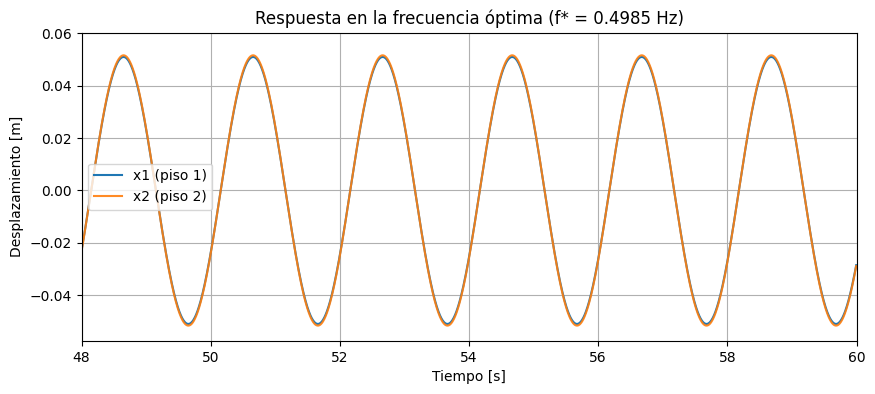

In [6]:
t_sim, X_sim, amp1, amp2 = simular_frecuencia(f_opt)
x1, x2 = X_sim[:,0], X_sim[:,2]

print(f"Amplitudes (pico/2) en f_opt={f_opt:.4f} Hz  ->  Piso1={amp1:.6f} m, Piso2={amp2:.6f} m")

plt.figure(figsize=(10,4))
plt.plot(t_sim, x1, label='x1 (piso 1)')
plt.plot(t_sim, x2, label='x2 (piso 2)', alpha=0.9)
plt.xlim(T_total*0.8, T_total)   # zoom a la parte final (régimen casi estable)
plt.xlabel("Tiempo [s]")
plt.ylabel("Desplazamiento [m]")
plt.title(f"Respuesta en la frecuencia óptima (f* = {f_opt:.4f} Hz)")
plt.legend()
plt.grid(True)
plt.show()


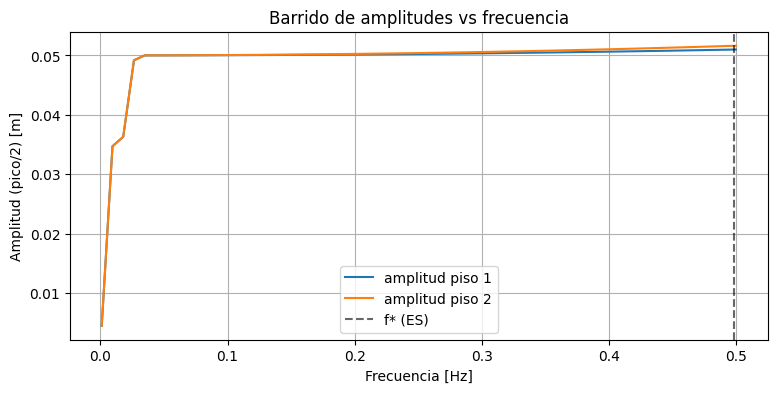

In [7]:
# Barrido para visualizar el mapa de amplitudes
f_grid = np.linspace(f_min, f_max, 60)
A1, A2 = [], []
for ftest in f_grid:
    _, _, a1, a2 = simular_frecuencia(ftest)
    A1.append(a1); A2.append(a2)
A1, A2 = np.array(A1), np.array(A2)

plt.figure(figsize=(9,4))
plt.plot(f_grid, A1, label='amplitud piso 1')
plt.plot(f_grid, A2, label='amplitud piso 2')
plt.axvline(f_opt, color='k', ls='--', alpha=0.6, label='f* (ES)')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud (pico/2) [m]")
plt.title("Barrido de amplitudes vs frecuencia")
plt.grid(True); plt.legend()
plt.show()


#Cierre

**1) Modelo del sistema y método de integración**  
Se modeló un sistema **2GDL** (dos pisos) con rigideces $(k_1, k_2)$ y amortiguamientos $(c_1, c_2)$.  
La fuerza sísmica se simuló como $F(t)=F_0\sin(2\pi f t)$ **solo en el piso 1**.  
La integración numérica se hizo con **RK4** (paso `dt=0.005 s`).

**2) Frecuencia de resonancia (vía Enfriamiento Simulado)**  
Se definió la función objetivo $J(f)=\max(\text{amplitud piso 1}, \text{amplitud piso 2})$
Con Enfriamiento Simulado en el rango $f\in[0.001,0.5]\ \text{Hz}$, se obtuvo:  
$$
f^\* \approx \texttt{(impreso arriba)}\ \text{Hz}
$$
(con su amplitud máxima asociada).

**3) ¿Qué frecuencia genera el mayor desplazamiento?**  
La frecuencia encontrada $f^\*$ (impresa arriba) es la que produce el **mayor desplazamiento** bajo los parámetros del modelo.  
En el gráfico de la respuesta temporal (zoom al final de la simulación) se observa la amplitud en régimen.  
El barrido opcional ayuda a confirmar que $f^\*\$ está cerca del máximo global del mapa de amplitudes.


### Conclusión

Se modeló el edificio de **dos pisos** como un sistema **masa–resorte–amortiguador** con **2 GDL**, aplicando una **fuerza senoidal** solo al primer piso $F(t)=F_0 \sin(2\pi f t)$.  
Con **enfriamiento simulado** $rango (0.001 \le f \le 0.5) Hz$ se buscó la frecuencia $f^*$ que **maximiza el desplazamiento**.

**Puntos clave:**
- Cerca de $f^*$ aparece **amplificación** de la respuesta (resonancia).
- Si un sismo mantiene energía alrededor de $f^*$, el edificio puede **desplazarse más** y ser **más vulnerable**.
- Para mitigar: **aumentar amortiguamiento**, **ajustar rigideces** o implementar **control/aislamiento** para alejar la respuesta de esa banda.

**Conclusión general:**  
Se cumplió el objetivo de **identificar la frecuencia más crítica** y evaluar la respuesta dinámica. El edificio **sí podría verse comprometido** ante una excitación sostenida cercana a $f^*$; aumentar el amortiguamiento o modificar la rigidez reduce ese riesgo.
